In [87]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

#Global normailization

hysea=False

if hysea is False:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_3.txt",skip_header=1,delimiter=",",usecols=1)
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_3.txt",skip_header=1,delimiter=",",usecols=(2,3,4))
    geoclaw_compare=np.load("/Users/seansantellanes/Downloads/geoclaw_toy_database.npz")
    data=geoclaw_compare["eta"][:-1]
    data.shape
elif hysea is True:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/mw_list_2.txt",skip_header=0,delimiter=" ")
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/location_df_thousand.txt",skip_header=0,delimiter=" ")
    mags=mags[np.argsort(mags[:,0])]
    mags=mags[:,1]
    centroid=centroid[np.argsort(centroid[:,0])]
    centroid=centroid[:,1:]
    geoclaw_compare=np.load("/Users/seansantellanes/Downloads/combined_eta_thousand.npz")
    data=geoclaw_compare["eta"][:]
    data=data.reshape(980,480,356)
    data=np.transpose(data,(0,2,1))
    data.shape


import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
geoclaw_compare=np.load("/Users/seansantellanes/Downloads/geoclaw_toy_database.npz")
data=geoclaw_compare["eta"][:-1]

data.shape

In [88]:
data.shape

(1000, 356, 480)

In [89]:
images=data

In [90]:
n=images.shape[0]
n

1000

In [91]:
X = images.reshape(n, -1)
X = (X - X.min()) / (X.max() - X.min())
X.shape

(1000, 170880)

In [92]:
S = cosine_similarity(X)

In [93]:
# Ignore self-similarity
np.fill_diagonal(S, -np.inf)

# Get upper triangle only
i, j = np.triu_indices(n, k=1)
scores = S[i, j]

In [94]:
real_event=np.load("/Users/seansantellanes/Downloads/real_event.npz")
real_event=real_event["eta"][0,:,:]
real_event_Norm=(real_event - real_event.min()) / (real_event.max() - real_event.min()) - real_event.mean()
real_event.shape


(356, 480)

In [95]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Database images
# shape: (1000, 480, 356)
X = images.reshape(n, -1)
#X = (X - X.min()) / (X.max() - X.min()) 
# Query image
# shape: (480, 356)
q = real_event.reshape(1, -1)

# Similarity of query to all database images
sims = cosine_similarity(q, X)[0]

# Top 5 matches
top5 = np.argsort(sims)[-10:][::-1]



In [96]:
X.shape

(1000, 170880)

In [97]:
q.shape

(1, 170880)

In [98]:
if hysea is False:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_2.txt",skip_header=1,delimiter=",",usecols=1)
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_2.txt",skip_header=1,delimiter=",",usecols=(2,3,4))

elif hysea is True:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/mw_list_2.txt",skip_header=0,delimiter=" ")
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/location_df_thousand.txt",skip_header=0,delimiter=" ")
    mags=mags[np.argsort(mags[:,0])]
    mags=mags[:,1]
    centroid=centroid[np.argsort(centroid[:,0])]
    centroid=centroid[:,1:]
print("Most similar images:")
mag_list=[]
cen_list=[]
for idx in top5:
    mag_list.append(mags[idx])
    cen_list.append(centroid[idx,:])
    print(f"Image {idx}: similarity={sims[idx]:.6f} and magnitude={mags[idx]:.2f} and centroid={centroid[idx,:]}")
mag_array=np.array(mag_list)
cen_array=np.array(cen_list)
print(f"Median Mw = {np.median(mag_array):.2f}")
print(f"Std Mw = {mag_array.std():.2f}")
print(f"Mean Centroid = {np.mean(cen_array,axis=0)}")
print(f"Std Centroid = {np.std(cen_array,axis=0)}")
print("True Mw = 7.00")
print("True Centroid = (169.309,-20.615,48)")

Most similar images:
Image 311: similarity=0.468419 and magnitude=7.45 and centroid=[166.399198 -14.048685  11.42    ]
Image 571: similarity=0.435491 and magnitude=7.91 and centroid=[167.761759 -17.964841  13.83    ]
Image 32: similarity=0.435132 and magnitude=6.69 and centroid=[168.040296 -17.205675  48.11    ]
Image 141: similarity=0.427785 and magnitude=7.18 and centroid=[167.569548 -15.736617  49.77    ]
Image 83: similarity=0.422050 and magnitude=7.30 and centroid=[167.200097 -15.531297  36.18    ]
Image 29: similarity=0.419796 and magnitude=7.05 and centroid=[167.034874 -15.206969  31.13    ]
Image 250: similarity=0.418301 and magnitude=7.10 and centroid=[168.683012 -20.464464   9.83    ]
Image 131: similarity=0.416644 and magnitude=7.08 and centroid=[169.188723 -21.090923  12.23    ]
Image 62: similarity=0.405536 and magnitude=7.26 and centroid=[168.133676 -18.121019  31.17    ]
Image 123: similarity=0.403744 and magnitude=7.14 and centroid=[169.196387 -21.013302  13.72    ]
Med

In [99]:
cov = np.cov(cen_array, rowvar=False)

print(cov)


[[  0.84928176  -2.29316355  -4.20181041]
 [ -2.29316355   6.51975824  19.16873675]
 [ -4.20181041  19.16873675 241.38083222]]


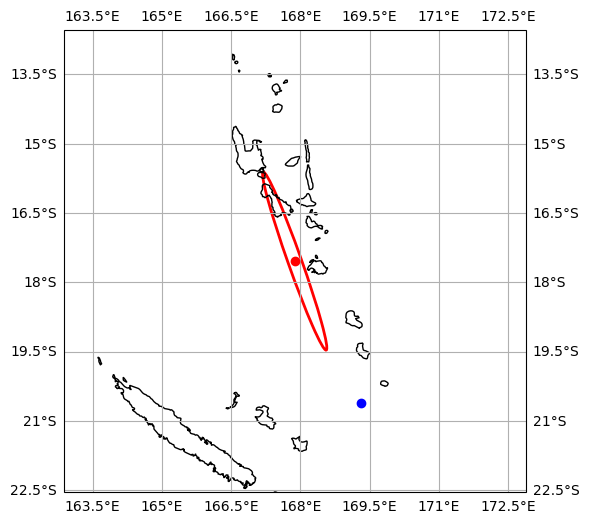

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import cartopy.crs as ccrs
from scipy.stats import chi2

# Center position
lon = 167.8754597
lat = -17.5408751

# Covariance matrix in longitude/latitude units (deg²)
cov=cov[:2,:2]

# 95% confidence ellipse
scale = np.sqrt(chi2.ppf(0.68, df=2))

# Eigen decomposition
vals, vecs = np.linalg.eigh(cov)

# Sort descending
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

# Full axis lengths
width = scale*np.sqrt(vals[0])
height = scale*np.sqrt(vals[1])

# Rotation angle (degrees CCW from x-axis)
angle = np.degrees(
    np.arctan2(vecs[1, 0], vecs[0, 0])
)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)

# Center point
ax.plot(
    lon,
    lat,
    "ro",
    transform=ccrs.PlateCarree()
)
ax.plot(
    169.309,
    -20.615,
    "bo",
    transform=ccrs.PlateCarree()
)
# Error ellipse
ellipse = Ellipse(
    xy=(lon, lat),
    width=width,
    height=height,
    angle=angle,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(ellipse)

ax.set_extent([
    lon - 5,
    lon + 5,
    lat -5,
    lat + 5
])

plt.show()

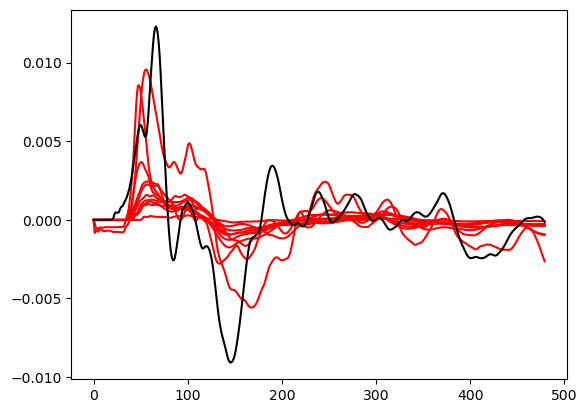

In [101]:
import matplotlib.pyplot as plt
q=q.reshape(356,480)
X=X.reshape(n,356,480)
for idx in top5:    
    plt.plot(X[idx,0,:]-X[idx,0,:].mean(),color="r")
plt.plot(q[0,:]-q[0,:].mean(),color="k")

In [102]:
q.shape

(356, 480)

In [103]:
from sklearn.neighbors import NearestNeighbors
X = images.reshape(images.shape[0], -1)
for idx in range(len(X[:,0])):
    X[idx,:] = X[idx,:] - X[idx,:].mean()
nn = NearestNeighbors(
    n_neighbors=10,
    metric="cosine"
)
nn.fit(X)

NearestNeighbors(metric='cosine', n_neighbors=10)

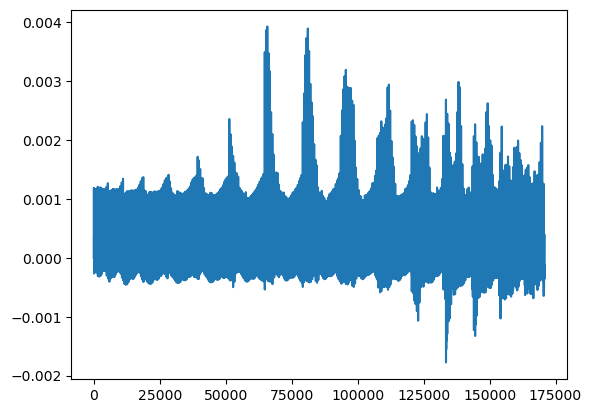

In [104]:
for idx in range(len(X[:,0])):
    X[idx] = X[idx] - X[idx].mean()
plt.plot(X[0])

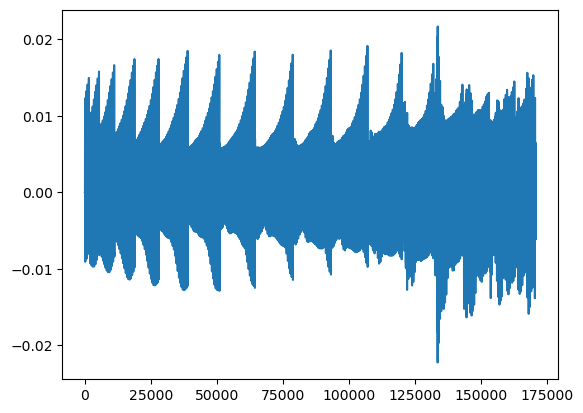

In [105]:
q = real_event.reshape(1, -1)
q = q - q.mean()
plt.plot(q[0])

In [106]:
q = real_event.reshape(1, -1)
q = q - q.mean()
distances, indices = nn.kneighbors(q)

print(indices[0])     # image IDs
print(distances[0])   # Euclidean distances

[311 571  32 141  83  29 250 131  62 123]
[0.53158034 0.56429031 0.56470044 0.57160647 0.57794573 0.58005835
 0.58142599 0.58334517 0.59446442 0.59622819]


In [107]:
print(mags[indices])
print(np.median(mags[indices]))
print(mags[indices].std())

[[7.4537 7.9074 6.6909 7.1838 7.296  7.0511 7.097  7.0769 7.2616 7.1402]]
7.162
0.29769593950875445


In [108]:


if hysea is False:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_2.txt",skip_header=1,delimiter=",",usecols=1)
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/dtopos_df_2.txt",skip_header=1,delimiter=",",usecols=(2,3,4))
    indices=indices[0]
elif hysea is True:
    mags=np.genfromtxt("/Users/seansantellanes/Downloads/mw_list_2.txt",skip_header=0,delimiter=" ",usecols=1)
    centroid=np.genfromtxt("/Users/seansantellanes/Downloads/location_df_thousand.txt",skip_header=0,delimiter=" ",usecols=(1,2,3))
    indices=indices[0]
print("Most similar images:")
mag_list=[]
cen_list=[]
for idx in indices:

    mag_list.append(mags[idx])
    cen_list.append(centroid[idx,:])
    print(f"Image {idx}:magnitude={mags[idx]:.2f} and centroid={centroid[idx,:]}")
mag_array=np.array(mag_list)
cen_array=np.array(cen_list)
print(f"Median Mw = {np.median(mag_array):.2f}")
print(f"Std Mw = {mag_array.std():.2f}")
print(f"Mean Centroid = {np.mean(cen_array,axis=0)}")
print(f"Std Centroid = {np.std(cen_array,axis=0)}")
print("True Mw = 7.00")
print("True Centroid = (169.309,-20.615,48)")

Most similar images:
Image 311:magnitude=7.45 and centroid=[166.399198 -14.048685  11.42    ]
Image 571:magnitude=7.91 and centroid=[167.761759 -17.964841  13.83    ]
Image 32:magnitude=6.69 and centroid=[168.040296 -17.205675  48.11    ]
Image 141:magnitude=7.18 and centroid=[167.569548 -15.736617  49.77    ]
Image 83:magnitude=7.30 and centroid=[167.200097 -15.531297  36.18    ]
Image 29:magnitude=7.05 and centroid=[167.034874 -15.206969  31.13    ]
Image 250:magnitude=7.10 and centroid=[168.683012 -20.464464   9.83    ]
Image 131:magnitude=7.08 and centroid=[169.188723 -21.090923  12.23    ]
Image 62:magnitude=7.26 and centroid=[168.133676 -18.121019  31.17    ]
Image 123:magnitude=7.14 and centroid=[169.196387 -21.013302  13.72    ]
Median Mw = 7.16
Std Mw = 0.30
Mean Centroid = [167.920757  -17.6383792  25.739    ]
Std Centroid = [ 0.87427318  2.4223506  14.739157  ]
True Mw = 7.00
True Centroid = (169.309,-20.615,48)


In [109]:
cov = np.cov(cen_array, rowvar=False)

print(cov)

[[  0.84928176  -2.29316355  -4.20181041]
 [ -2.29316355   6.51975824  19.16873675]
 [ -4.20181041  19.16873675 241.38083222]]


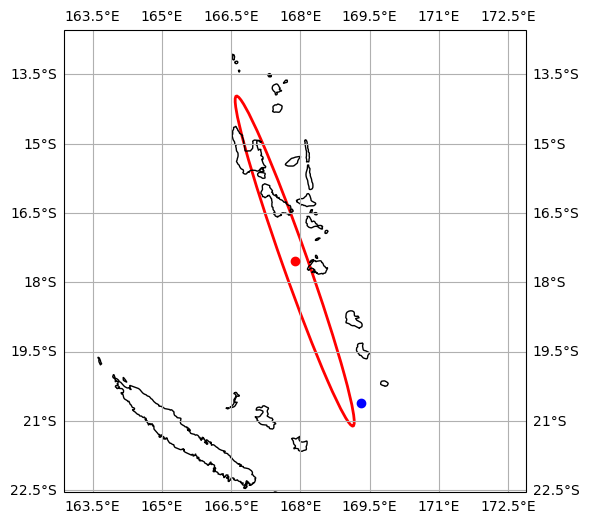

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import cartopy.crs as ccrs
from scipy.stats import chi2

# Center position
lon = 167.8754597
lat = -17.5408751

# Covariance matrix in longitude/latitude units (deg²)
cov=cov[:2,:2]

# 95% confidence ellipse
scale = np.sqrt(chi2.ppf(0.98, df=2))

# Eigen decomposition
vals, vecs = np.linalg.eigh(cov)

# Sort descending
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

# Full axis lengths
width = scale*np.sqrt(vals[0])
height = scale*np.sqrt(vals[1])

# Rotation angle (degrees CCW from x-axis)
angle = np.degrees(
    np.arctan2(vecs[1, 0], vecs[0, 0])
)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)

# Center point
ax.plot(
    lon,
    lat,
    "ro",
    transform=ccrs.PlateCarree()
)
ax.plot(
    169.309,
    -20.615,
    "bo",
    transform=ccrs.PlateCarree()
)
# Error ellipse
ellipse = Ellipse(
    xy=(lon, lat),
    width=width,
    height=height,
    angle=angle,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(ellipse)

ax.set_extent([
    lon - 5,
    lon + 5,
    lat -5,
    lat + 5
])

plt.show()

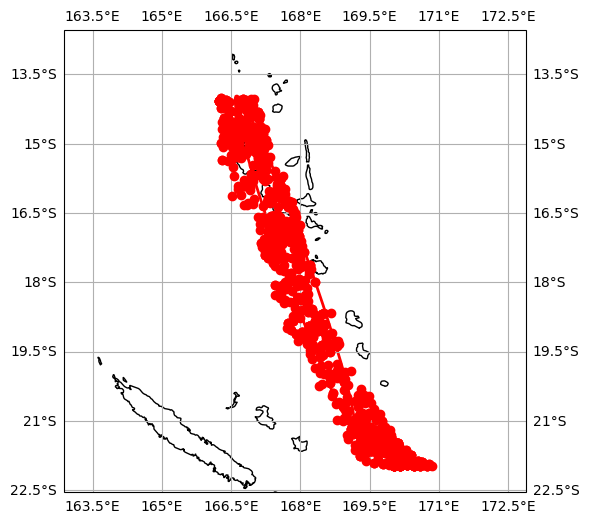

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import cartopy.crs as ccrs
from scipy.stats import chi2

# Center position
lon = 167.8754597
lat = -17.5408751

# Covariance matrix in longitude/latitude units (deg²)
cov=cov[:2,:2]

# 95% confidence ellipse
scale = np.sqrt(chi2.ppf(0.98, df=2))

# Eigen decomposition
vals, vecs = np.linalg.eigh(cov)

# Sort descending
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

# Full axis lengths
width = scale*np.sqrt(vals[0])
height = scale*np.sqrt(vals[1])

# Rotation angle (degrees CCW from x-axis)
angle = np.degrees(
    np.arctan2(vecs[1, 0], vecs[0, 0])
)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)

# Center point
ax.plot(
    centroid[:,0],
    centroid[:,1],
    "ro",
    transform=ccrs.PlateCarree()
)

# Error ellipse
ellipse = Ellipse(
    xy=(lon, lat),
    width=width,
    height=height,
    angle=angle,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(ellipse)

ax.set_extent([
    lon - 5,
    lon + 5,
    lat -5,
    lat + 5
])

plt.show()

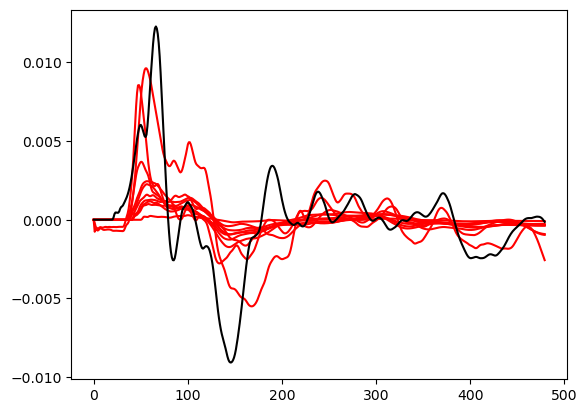

In [112]:
import matplotlib.pyplot as plt
X=X.reshape(n,356,480)
for idx in indices:  
    plt.plot(X[idx,0,:]-X.mean(),color="r")
plt.plot(real_event[0,:]-real_event.mean(),color="k")